[00] lin_uni (d=1): 1.87*x1 + 2.01
[01] lin_bi (d=2): 1.56*x1 + 1.59*x2 - 2.91
[02] poly2_uni (d=1): 2.48*x1**2 + 1.92*x1 - 0.68
[03] poly2_bi (d=2): 0.55*x1**2 + 2.45*x1*x2 + 1.65*x1 + 2.95*x2**2 + 0.8*x2 + 0.86
[04] lin_pm_log (d=1): -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
[05] lin_pm_sqrt (d=1): -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
[06] rat_linlin_pole_extrap_only (d=2): (2.83*x1 - 1.49*x2 + 0.88)/(0.74*x1 + 0.52*x2 - 2.94)
[07] rat_linlin_pole_train_only (d=2): (-1.67*x1 - 1.54*x2 + 0.77)/(0.9*x1 + 2.6*x2 + 2.49)
[08] rat_poly2poly2_pole_extrap_only (d=2): (-0.55*x1**2 + 2.65*x1*x2 + 2.63*x1 - 1.96*x2**2 + 1.02*x2 + 1.79)/(1.09*x1**2 - 2.5*x1*x2 - 2.73*x1 + 1.47*x2**2 + 2.49*x2 + 2.85)
[09] rat_poly2poly2_pole_train_only (d=2): (2.33*x1**2 - 2.57*x1*x2 - 1.95*x1 + 1.03*x2**2 + 1.13*x2 + 1.43)/(-1.57*x1**2 + 0.54*x1*x2 + 1.63*x1 - 2.03*x2**2 + 1.56*x2 + 2.58)


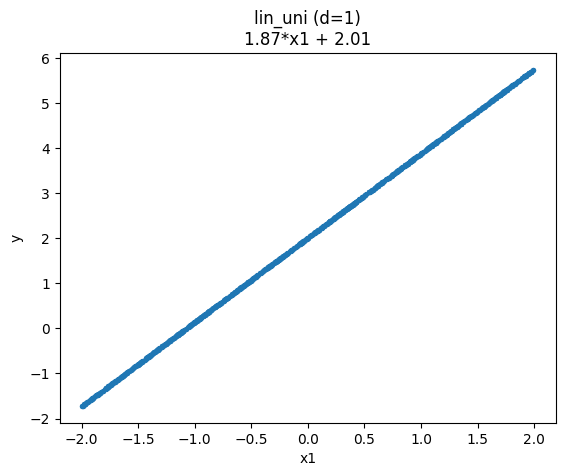

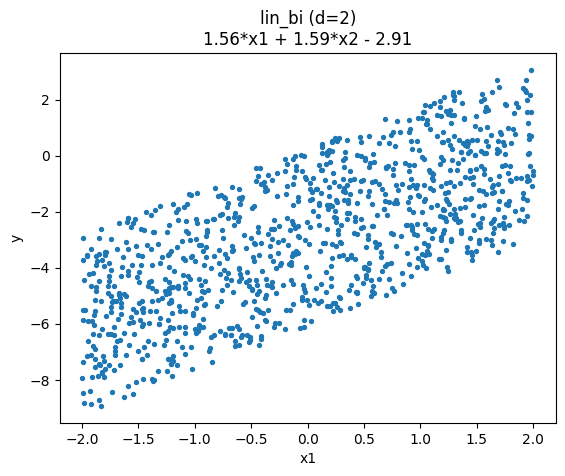

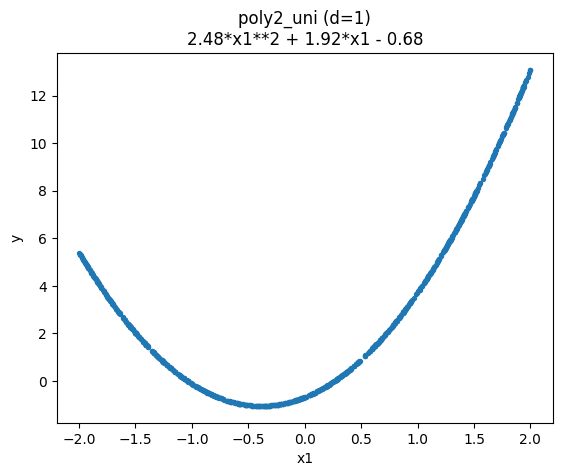

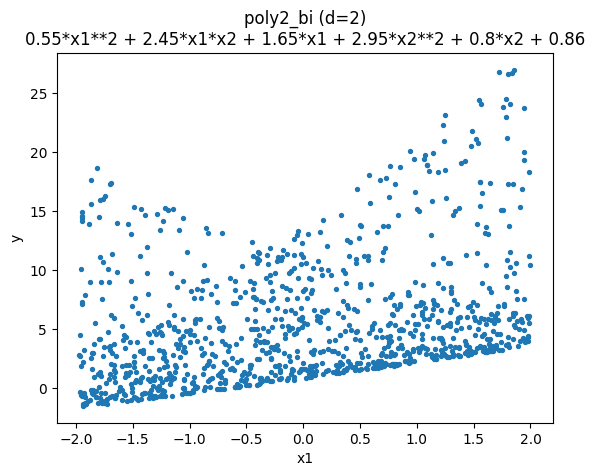

<lambdifygenerated-4712>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4713>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4714>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4715>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4716>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4717>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4719>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 1.92*log(2.04*x1 + 2.04) - 2.44
<lambdifygenerated-4720>:2: RuntimeWarning: invalid value encountered in log
  return -1.54*x1 - 

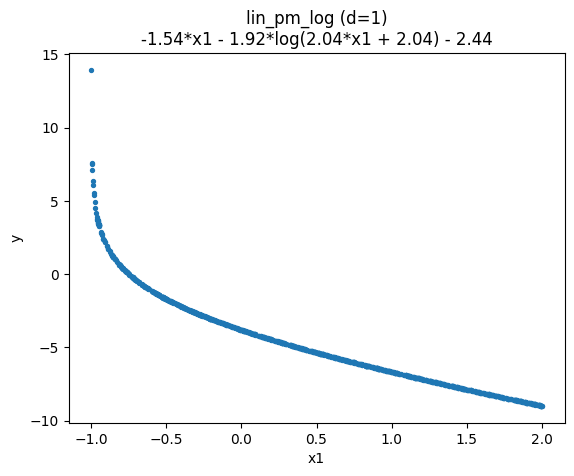

<lambdifygenerated-4739>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4740>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4741>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4742>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4743>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4744>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4745>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.4*x1 + 2.17*sqrt(-1.03*x1 - 1.29) - 2.24
<lambdifygenerated-4746>:2: RuntimeWarning: invalid value encountered in sqrt
  ret

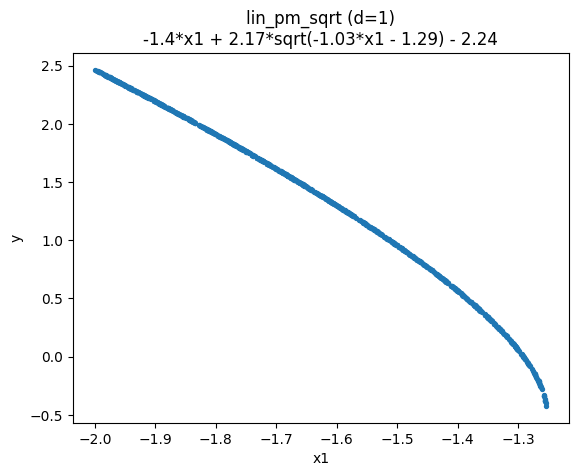

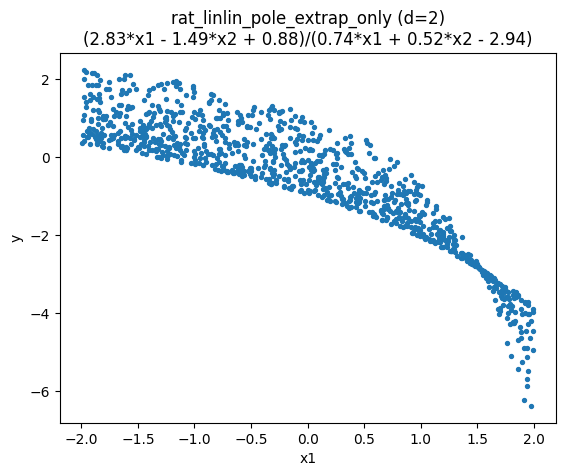

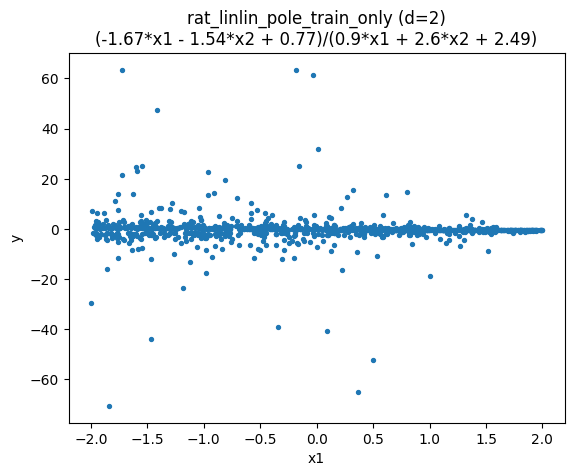

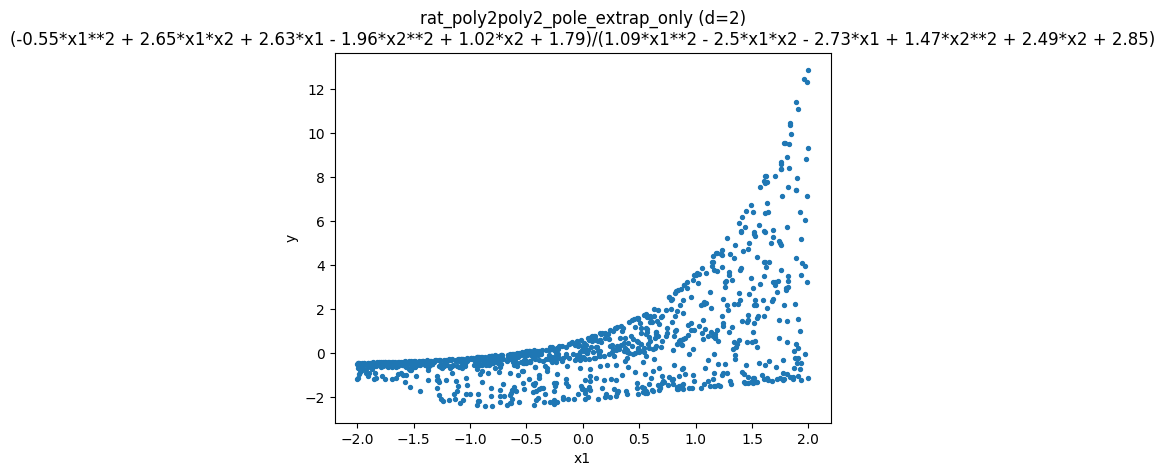

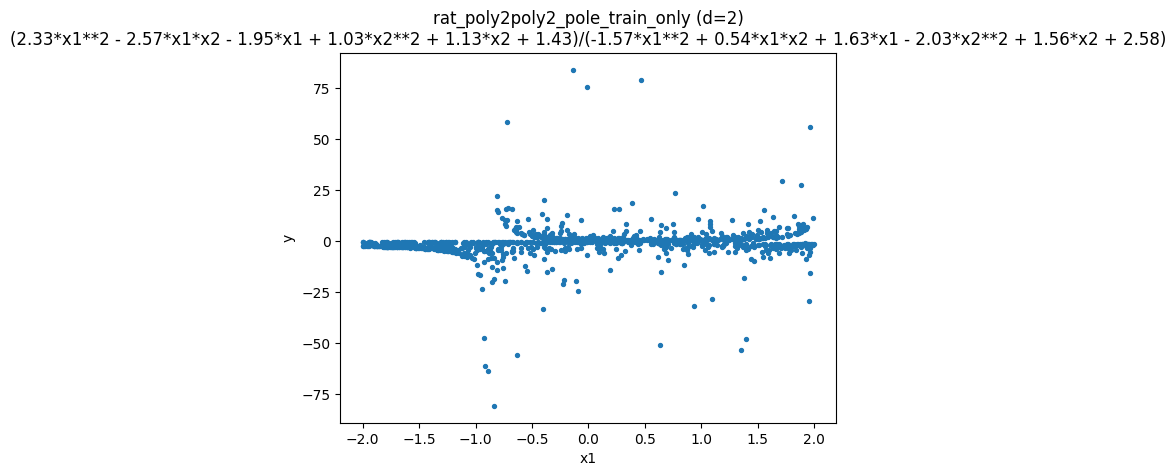


Saved: data/sr_benchmark.h5


In [1]:
from __future__ import annotations

from typing import List, Tuple

from config.benchmark_config import DataCFG

import h5py
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp


def _signed_uniform(rng: np.random.RandomState, min_abs: float, max_abs: float, decimals: int) -> float:
    mag = rng.uniform(min_abs, max_abs)
    sgn = -1.0 if rng.rand() < 0.5 else 1.0
    return float(np.round(sgn * mag, decimals))


def _coef(rng: np.random.RandomState, cfg: DataCFG) -> float:
    return _signed_uniform(rng, cfg.coeff_min_abs, cfg.coeff_max_abs, cfg.coeff_decimals)


def _inner_const(rng: np.random.RandomState, cfg: DataCFG) -> float:
    return _signed_uniform(rng, cfg.inner_const_min_abs, cfg.inner_const_max_abs, cfg.inner_const_decimals)


def _sample_X_uniform(rng: np.random.RandomState, n: int, d: int, low: float, high: float) -> np.ndarray:
    return rng.uniform(low, high, size=(n, d)).astype(np.float64, copy=False)


def _sample_X_extrap(rng: np.random.RandomState, n: int, d: int, cfg: DataCFG) -> np.ndarray:
    u = rng.rand(n, d)
    X = np.empty((n, d), dtype=np.float64)
    mask = u < 0.5
    X[mask] = rng.uniform(cfg.extrap_a_low, cfg.extrap_a_high, size=mask.sum())
    X[~mask] = rng.uniform(cfg.extrap_b_low, cfg.extrap_b_high, size=(~mask).sum())
    return X


def _eval_expr_numpy(expr: sp.Expr, xs: List[sp.Symbol], X: np.ndarray) -> np.ndarray:
    f = sp.lambdify(xs, expr, modules=["numpy"])
    y = f(*[X[:, i] for i in range(X.shape[1])])
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return y


def _finite_mask(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return np.isfinite(y)


def _accept_mask(y: np.ndarray, y_abs_max: float) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return np.isfinite(y) & (np.abs(y) <= y_abs_max)


def _sample_and_eval_until_n(
    *,
    rng: np.random.RandomState,
    cfg: DataCFG,
    expr: sp.Expr,
    xs: List[sp.Symbol],
    n_target: int,
    d: int,
    sampler,
    y_abs_max: float = 100,
) -> Tuple[np.ndarray, np.ndarray]:
    X_acc: List[np.ndarray] = []
    y_acc: List[np.ndarray] = []
    n_ok = 0

    for _ in range(cfg.max_rounds):
        n_need = n_target - n_ok
        if n_need <= 0:
            break

        n_batch = cfg.batch_size if n_need > cfg.batch_size else n_need
        Xb = sampler(n_batch, d)
        yb = _eval_expr_numpy(expr, xs, Xb)

        m = _accept_mask(yb, y_abs_max)

        if np.any(m):
            X_acc.append(Xb[m])
            y_acc.append(yb[m])
            n_ok += int(np.sum(m))

    if n_ok < n_target:
        raise RuntimeError(f"Not enough accepted samples for expr={expr}. Collected {n_ok}/{n_target}.")

    X = np.vstack(X_acc)[:n_target]
    y = np.concatenate(y_acc)[:n_target]
    return X, y


def _grid_minabs_2d(expr: sp.Expr, xs: List[sp.Symbol], low: float, high: float, n_grid: int) -> float:
    g = sp.lambdify(xs, expr, modules=["numpy"])
    grid = np.linspace(low, high, n_grid, dtype=np.float64)
    X0, X1 = np.meshgrid(grid, grid, indexing="xy")
    v = np.asarray(g(X0, X1), dtype=np.float64)
    return float(np.min(np.abs(v)))


def _grid_minabs_extrap_2d(expr: sp.Expr, xs: List[sp.Symbol], cfg: DataCFG) -> Tuple[float, float]:
    a = _grid_minabs_2d(expr, xs, cfg.extrap_a_low, cfg.extrap_a_high, cfg.grid_n)
    b = _grid_minabs_2d(expr, xs, cfg.extrap_b_low, cfg.extrap_b_high, cfg.grid_n)
    return a, b


def _pole_presence(minabs: float, eps: float) -> bool:
    return minabs < eps


def _no_pole_presence(minabs: float, delta: float) -> bool:
    return minabs > delta


def _rand_linear_2d(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol, x2: sp.Symbol) -> sp.Expr:
    return sp.Float(_coef(rng, cfg)) * x1 + sp.Float(_coef(rng, cfg)) * x2 + sp.Float(_coef(rng, cfg))


def _rand_poly2_2d(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol, x2: sp.Symbol) -> sp.Expr:
    return (
        sp.Float(_coef(rng, cfg)) * x1**2
        + sp.Float(_coef(rng, cfg)) * x1 * x2
        + sp.Float(_coef(rng, cfg)) * x2**2
        + sp.Float(_coef(rng, cfg)) * x1
        + sp.Float(_coef(rng, cfg)) * x2
        + sp.Float(_coef(rng, cfg))
    )


def _make_random_rational(
    *,
    rng: np.random.RandomState,
    cfg: DataCFG,
    kind: str,
    want_pole_in_train: bool,
    want_pole_in_extrap: bool,
) -> sp.Expr:
    x1, x2 = sp.symbols("x1 x2", real=True)
    xs = [x1, x2]

    if kind == "linlin":
        make_num = lambda: _rand_linear_2d(rng, cfg, x1, x2)
        make_den = lambda: _rand_linear_2d(rng, cfg, x1, x2)
    elif kind == "poly2poly2":
        make_num = lambda: _rand_poly2_2d(rng, cfg, x1, x2)
        make_den = lambda: _rand_poly2_2d(rng, cfg, x1, x2)
    else:
        raise ValueError(kind)

    for _ in range(cfg.max_rational_trials):
        p = make_num()
        q = make_den()

        minabs_train = _grid_minabs_2d(q, xs, cfg.train_low, cfg.train_high, cfg.grid_n)
        minabs_exA, minabs_exB = _grid_minabs_extrap_2d(q, xs, cfg)

        pole_train = _pole_presence(minabs_train, cfg.pole_eps)
        pole_ex = _pole_presence(minabs_exA, cfg.pole_eps) or _pole_presence(minabs_exB, cfg.pole_eps)

        nopole_train = _no_pole_presence(minabs_train, cfg.no_pole_delta)
        nopole_ex = _no_pole_presence(minabs_exA, cfg.no_pole_delta) and _no_pole_presence(minabs_exB, cfg.no_pole_delta)

        ok = True
        ok = ok and (pole_train if want_pole_in_train else nopole_train)
        ok = ok and (pole_ex if want_pole_in_extrap else nopole_ex)

        if ok:
            return sp.simplify(p / q)

    raise RuntimeError(f"Could not sample a rational ({kind}) with requested pole placement.")


def _make_expressions(rng: np.random.RandomState, cfg: DataCFG) -> List[Tuple[str, int, sp.Expr]]:
    x1, x2 = sp.symbols("x1 x2", real=True)

    out: List[Tuple[str, int, sp.Expr]] = []

    out.append(("lin_uni", 1, sp.Float(_coef(rng, cfg)) * x1 + sp.Float(_coef(rng, cfg))))
    out.append(
        ("lin_bi", 2, sp.Float(_coef(rng, cfg)) * x1 + sp.Float(_coef(rng, cfg)) * x2 + sp.Float(_coef(rng, cfg)))
    )
    out.append(
        ("poly2_uni", 1, sp.Float(_coef(rng, cfg)) * x1**2 + sp.Float(_coef(rng, cfg)) * x1 + sp.Float(_coef(rng, cfg)))
    )
    out.append(
        (
            "poly2_bi",
            2,
            sp.Float(_coef(rng, cfg)) * x1**2
            + sp.Float(_coef(rng, cfg)) * x1 * x2
            + sp.Float(_coef(rng, cfg)) * x2**2
            + sp.Float(_coef(rng, cfg)) * x1
            + sp.Float(_coef(rng, cfg)) * x2
            + sp.Float(_coef(rng, cfg)),
        )
    )

    s = -1.0 if rng.rand() < 0.5 else 1.0
    out.append(
        (
            "lin_pm_log",
            1,
            sp.Float(_coef(rng, cfg)) * x1
            + sp.Float(_coef(rng, cfg))
            + sp.Float(_coef(rng, cfg) * s) * sp.log(sp.Float(_coef(rng, cfg)) * x1 + sp.Float(_inner_const(rng, cfg))),
        )
    )

    s = -1.0 if rng.rand() < 0.5 else 1.0
    out.append(
        (
            "lin_pm_sqrt",
            1,
            sp.Float(_coef(rng, cfg)) * x1
            + sp.Float(_coef(rng, cfg))
            + sp.Float(_coef(rng, cfg) * s) * sp.sqrt(sp.Float(_coef(rng, cfg)) * x1 + sp.Float(_inner_const(rng, cfg))),
        )
    )

    out.append(
        (
            "rat_linlin_pole_extrap_only",
            2,
            _make_random_rational(rng=rng, cfg=cfg, kind="linlin", want_pole_in_train=False, want_pole_in_extrap=True),
        )
    )
    out.append(
        (
            "rat_linlin_pole_train_only",
            2,
            _make_random_rational(rng=rng, cfg=cfg, kind="linlin", want_pole_in_train=True, want_pole_in_extrap=False),
        )
    )
    out.append(
        (
            "rat_poly2poly2_pole_extrap_only",
            2,
            _make_random_rational(rng=rng, cfg=cfg, kind="poly2poly2", want_pole_in_train=False, want_pole_in_extrap=True),
        )
    )
    out.append(
        (
            "rat_poly2poly2_pole_train_only",
            2,
            _make_random_rational(rng=rng, cfg=cfg, kind="poly2poly2", want_pole_in_train=True, want_pole_in_extrap=False),
        )
    )

    return out


def _print_exprs(exprs: List[Tuple[str, int, sp.Expr]]) -> None:
    for i, (name, d, expr) in enumerate(exprs):
        print(f"[{i:02d}] {name} (d={d}): {expr}")


def main() -> None:
    cfg = DataCFG()
    rng = np.random.RandomState(cfg.seed)

    x1, x2 = sp.symbols("x1 x2", real=True)
    sym_by_d = {1: [x1], 2: [x1, x2]}

    exprs = _make_expressions(rng, cfg)
    _print_exprs(exprs)

    with h5py.File(cfg.h5_path, "w") as f:
        dt = h5py.string_dtype(encoding="utf-8")

        for idx, (name, d, expr) in enumerate(exprs):
            g = f.create_group(f"expr_{idx:03d}_{name}")
            g.create_dataset("sympy_str", data=str(expr), dtype=dt)

            xs = sym_by_d[d]

            train_sampler = lambda n, dd: _sample_X_uniform(rng, n, dd, cfg.train_low, cfg.train_high)
            interp_sampler = lambda n, dd: _sample_X_uniform(rng, n, dd, cfg.train_low, cfg.train_high)
            extrap_sampler = lambda n, dd: _sample_X_extrap(rng, n, dd, cfg)

            Xtr, ytr = _sample_and_eval_until_n(
                rng=rng, cfg=cfg, expr=expr, xs=xs, n_target=cfg.n_train, d=d, sampler=train_sampler
            )
            Xte_i, yte_i = _sample_and_eval_until_n(
                rng=rng, cfg=cfg, expr=expr, xs=xs, n_target=cfg.n_test_interp, d=d, sampler=interp_sampler
            )
            Xte_e, yte_e = _sample_and_eval_until_n(
                rng=rng, cfg=cfg, expr=expr, xs=xs, n_target=cfg.n_test_extrap, d=d, sampler=extrap_sampler
            )

            plt.figure()
            plt.scatter(Xtr[:, 0], ytr, s=8)
            plt.xlabel("x1")
            plt.ylabel("y")
            plt.title(f"{name} (d={d})\n{expr}")
            plt.show()

            g_tr = g.create_group("train")
            g_tr.create_dataset("X", data=Xtr)
            g_tr.create_dataset("y", data=ytr)

            g_ti = g.create_group("test_interp")
            g_ti.create_dataset("X", data=Xte_i)
            g_ti.create_dataset("y", data=yte_i)

            g_te = g.create_group("test_extrap")
            g_te.create_dataset("X", data=Xte_e)
            g_te.create_dataset("y", data=yte_e)

    print(f"\nSaved: {cfg.h5_path}")


if __name__ == "__main__":
    main()
